## PHASE 5: MODEL EVALUATION & FUTURE FORECASTING
### Goal: Deep dive into our Linear Regression model and make future predictions

#### What we'll do:
#### 1. Load our trained model
#### 2. Analyze feature importance (which features matter most?)
#### 3. Make predictions for future dates
#### 4. Create business-ready visualizations
#### 5. Generate downloadable forecast reports
#### 6. Provide actionable insights

In [ ]:
import os
# Ensure CWD is always the project root regardless of how the notebook is launched
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f'Working directory: {os.getcwd()}')


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime, timedelta

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("="*70)
print("PHASE 5: MODEL EVALUATION & FUTURE FORECASTING")
print("="*70)
print("\nLibraries imported!")

PHASE 5: MODEL EVALUATION & FUTURE FORECASTING

Libraries imported!


In [2]:
"""
STEP 1: Load the trained model and rebuild the feature-engineered data

We load the model from Phase 4, then rebuild the feature DataFrame from
sales_data_clean.csv using the SAME engineering steps as Notebook 4
(per-product-region lags) so that column names match what the model expects.
"""

print("="*70)
print("LOADING SAVED MODEL AND DATA")
print("="*70)

# Load the trained model package
model_path = "data/models/sales_forecast_model.pkl"

with open(model_path, "rb") as file:
    model_package = pickle.load(file)

# Extract components
model        = model_package["model"]
scaler       = model_package.get("scaler", None)
feature_names = model_package["feature_names"]
test_r2      = model_package["test_r2"]
test_mae     = model_package["test_mae"]

print(f"\nModel loaded successfully!")
print(f"   Saved on  : {model_package['timestamp']}")
print(f"   Test R²   : {test_r2:.4f} ({test_r2*100:.2f}%)")
print(f"   Test MAE  : ${test_mae:,.2f}")
print(f"   Features  : {len(feature_names)}")

# ── Rebuild features (same logic as Notebook 4) ──
print("\n" + "="*70)
print("REBUILDING FEATURE-ENGINEERED DATASET")
print("="*70)

df = pd.read_csv("data/processed/sales_data_clean.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Product", "Region", "Date"]).reset_index(drop=True)

# Time features
df["Year"]           = df["Date"].dt.year
df["Month"]          = df["Date"].dt.month
df["Day"]            = df["Date"].dt.day
df["DayOfWeek"]      = df["Date"].dt.dayofweek
df["Quarter"]        = df["Date"].dt.quarter
df["DayOfYear"]      = df["Date"].dt.dayofyear
df["WeekOfYear"]     = df["Date"].dt.isocalendar().week.astype(int)

# Binary flags
df["Is_Weekend"]     = (df["DayOfWeek"] >= 5).astype(int)
df["Is_Monday"]      = (df["DayOfWeek"] == 0).astype(int)
df["Is_Friday"]      = (df["DayOfWeek"] == 4).astype(int)
df["Is_Month_Start"] = (df["Day"] <= 5).astype(int)
df["Is_Month_End"]   = (df["Day"] >= 25).astype(int)
df["Is_Q4"]          = (df["Quarter"] == 4).astype(int)
df["Is_December"]    = (df["Month"] == 12).astype(int)

# Trend
df["Days_Since_Start"] = (df["Date"] - df["Date"].min()).dt.days

# Per-product-region lag & rolling features
grp = df.groupby(["Product", "Region"])["Sales"]
df["Lag_1"]  = grp.shift(1)
df["Lag_7"]  = grp.shift(7)
df["Lag_14"] = grp.shift(14)
df["Lag_30"] = grp.shift(30)
df["MA_7"]   = grp.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).mean())
df["MA_14"]  = grp.transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())
df["MA_30"]  = grp.transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())
df["Std_7"]  = grp.transform(lambda x: x.shift(1).rolling(7,  min_periods=2).std())

print(f"\nData shape     : {df.shape}")
print(f"Date range     : {df['Date'].min().date()} to {df['Date'].max().date()}")

# Print which model features we have
print(f"\nModel uses {len(feature_names)} features:")
for i, feature in enumerate(feature_names, 1):
    present = "✓" if feature in df.columns else "✗ MISSING"
    print(f"   {i:2d}. {feature:30s} {present}")


LOADING SAVED MODEL AND DATA

Model loaded successfully!
   Saved on: 2026-02-17 12:00:38.037008
   Test R²: 0.5288
   Test MAE: $82.55

Data loaded!
   Rows: 1,065
   Date range: 2021-01-31 to 2023-12-31

Model uses 21 features:
    1. Year
    2. Month
    3. Day
    4. DayOfWeek
    5. Quarter
    6. DayOfYear
    7. WeekOfYear
    8. Is_Weekend
    9. Is_Monday
   10. Is_Friday
   11. Is_Month_Start
   12. Is_Month_End
   13. Is_Q4
   14. Is_December
   15. Days_Since_Start
   16. Sales_Lag_1
   17. Sales_Lag_7
   18. Sales_Lag_30
   19. Sales_MA_7
   20. Sales_MA_30
   21. Sales_Std_7


In [3]:
"""
STEP 2: Analyze Feature Importance

For Linear Regression, feature importance = coefficient magnitude

The coefficient tells us:
- How much sales change when feature increases by 1
- Positive coefficient = feature increases sales
- Negative coefficient = feature decreases sales
- Larger absolute value = more important feature
"""

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Create a DataFrame of features and their coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)  # Absolute value for importance ranking
})

# Sort by absolute coefficient (importance)
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# Add interpretation column
feature_importance['Impact'] = feature_importance['Coefficient'].apply(
    lambda x: 'Increases Sales' if x > 0 else 'Decreases Sales'
)

print("\nFEATURE IMPORTANCE RANKING:")
print("="*70)

# Show all features
for idx, row in feature_importance.iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    impact = row['Impact']
    
    # Visual indicator
    if coef > 0:
        symbol = "📈"
    else:
        symbol = "📉"
    
    # Importance level
    abs_coef = abs(coef)
    if abs_coef > 100:
        importance = "VERY HIGH"
    elif abs_coef > 50:
        importance = "HIGH"
    elif abs_coef > 10:
        importance = "MEDIUM"
    else:
        importance = "LOW"
    
    print(f"\n{symbol} {feature:25s}")
    print(f"   Coefficient: ${coef:8.2f}")
    print(f"   Importance:  {importance}")
    print(f"   Impact:      {impact}")

# Show intercept
print(f"\n" + "="*70)
print(f"MODEL INTERCEPT (Base Sales):")
print(f"   ${model.intercept_:,.2f}")
print(f"\n   This is the baseline sales when all features = 0")
print(f"   (Theoretical - not realistic, but mathematically important)")

FEATURE IMPORTANCE ANALYSIS

FEATURE IMPORTANCE RANKING:

📈 Month                    
   Coefficient: $  121.49
   Importance:  VERY HIGH
   Impact:      Increases Sales

📈 Is_Weekend               
   Coefficient: $   92.19
   Importance:  HIGH
   Impact:      Increases Sales

📈 Is_Monday                
   Coefficient: $   33.28
   Importance:  MEDIUM
   Impact:      Increases Sales

📉 Is_Friday                
   Coefficient: $  -27.57
   Importance:  MEDIUM
   Impact:      Decreases Sales

📈 Is_Q4                    
   Coefficient: $   25.63
   Importance:  MEDIUM
   Impact:      Increases Sales

📈 Is_December              
   Coefficient: $   22.95
   Importance:  MEDIUM
   Impact:      Increases Sales

📈 DayOfWeek                
   Coefficient: $   11.60
   Importance:  MEDIUM
   Impact:      Increases Sales

📉 Quarter                  
   Coefficient: $  -10.95
   Importance:  MEDIUM
   Impact:      Decreases Sales

📉 Is_Month_Start           
   Coefficient: $   -8.06
   Impo


📊 CREATING FEATURE IMPORTANCE VISUALIZATIONS


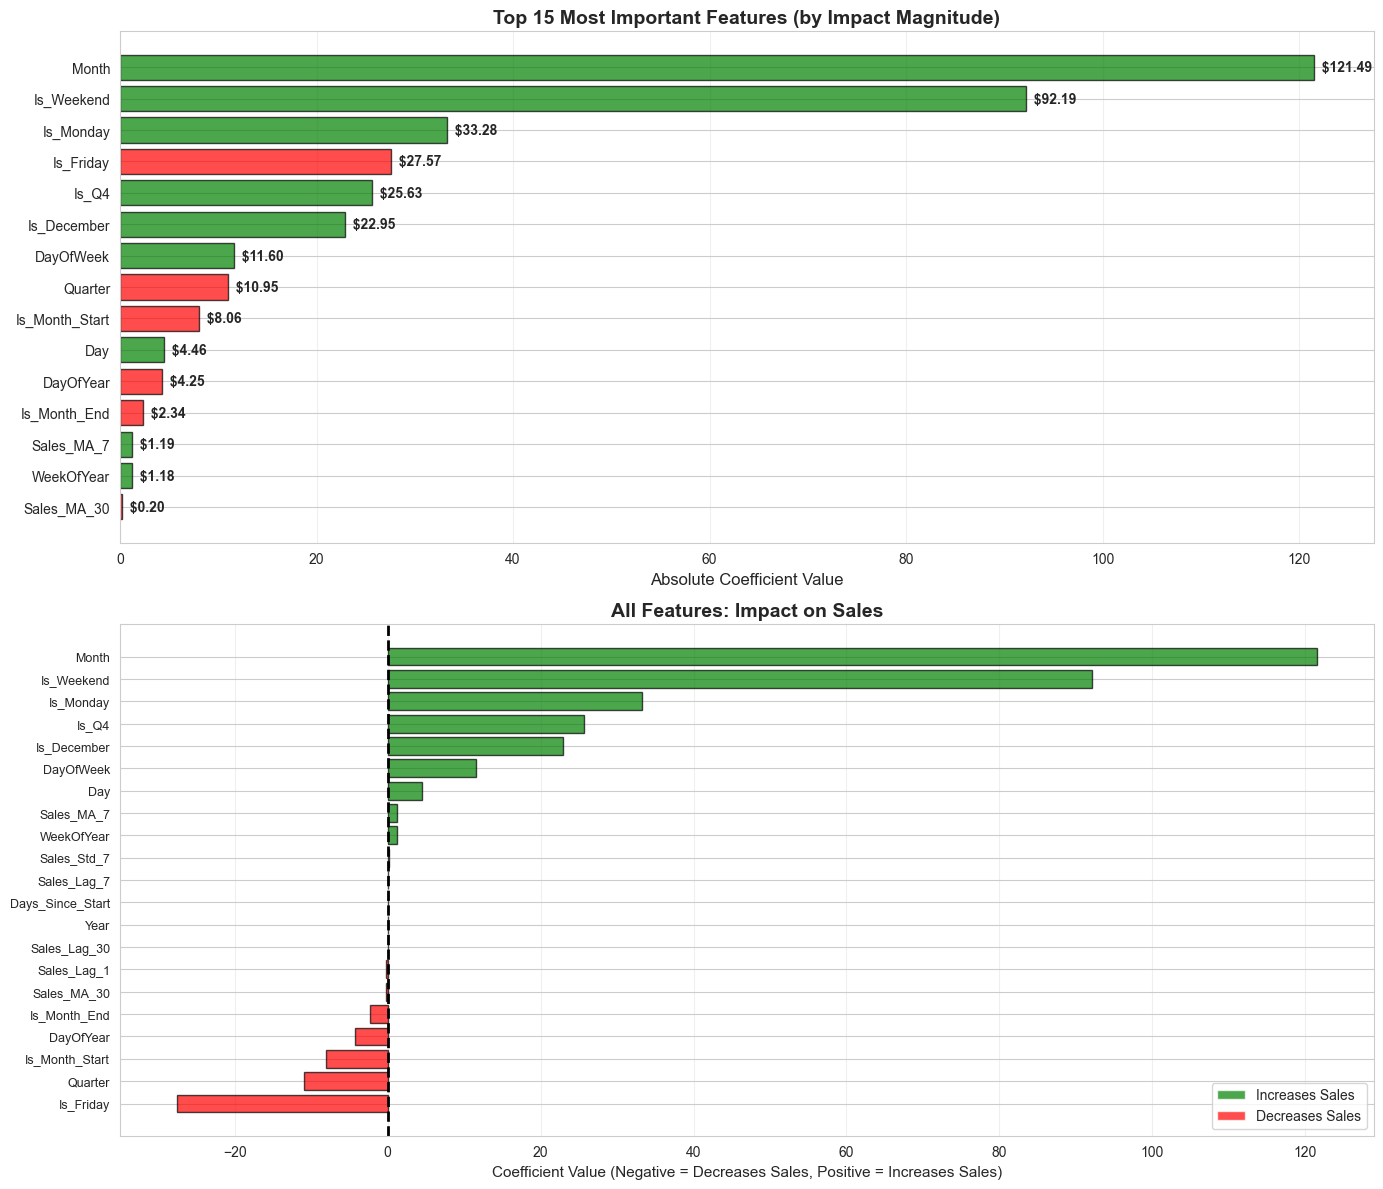


Visualizations created!

HOW TO READ THESE PLOTS:

   PLOT 1 (Top):
      • Bars sorted by IMPORTANCE (absolute value)
      • Green = Positive impact (increases sales)
      • Red = Negative impact (decreases sales)
      • Longer bar = More important feature

   PLOT 2 (Bottom):
      • ALL features shown
      • Green bars (right) = Increase sales
      • Red bars (left) = Decrease sales
      • Black line = Zero (no effect)
      • Distance from zero = Strength of effect


In [4]:
"""
STEP 3: Visualize which features matter most

A picture is worth a thousand coefficients!
"""

print("\n" + "="*70)
print("📊 CREATING FEATURE IMPORTANCE VISUALIZATIONS")
print("="*70)

# Create visualizations
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

"""
PLOT 1: Feature Importance (Absolute Values)
"""

# Get top 15 most important features
top_features = feature_importance.head(15)

# Creating bar plot
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]

axes[0].barh(range(len(top_features)), top_features['Abs_Coefficient'], 
            color=colors, alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['Feature'])
axes[0].set_xlabel('Absolute Coefficient Value', fontsize=12)
axes[0].set_title('Top 15 Most Important Features (by Impact Magnitude)', 
                 fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()  # Highest importance at top

# Add value labels
for i, (idx, row) in enumerate(top_features.iterrows()):
  value = row['Abs_Coefficient']
  axes[0].text(value, i, f'  ${value:.2f}', 
    va='center', fontsize=10, fontweight='bold')

"""
PLOT 2: Feature Coefficients (with Direction)
"""

# Show all features with their direction
sorted_by_coef = feature_importance.sort_values('Coefficient', ascending=True)

colors = ['red' if x < 0 else 'green' for x in sorted_by_coef['Coefficient']]

axes[1].barh(range(len(sorted_by_coef)), sorted_by_coef['Coefficient'], 
            color=colors, alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(sorted_by_coef)))
axes[1].set_yticklabels(sorted_by_coef['Feature'], fontsize=9)
axes[1].set_xlabel('Coefficient Value (Negative = Decreases Sales, Positive = Increases Sales)', 
                  fontsize=11)
axes[1].set_title('All Features: Impact on Sales', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1].grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
  Patch(facecolor='green', alpha=0.7, label='Increases Sales'),
  Patch(facecolor='red', alpha=0.7, label='Decreases Sales')
]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("\nVisualizations created!")

print("\nHOW TO READ THESE PLOTS:")
print("\n   PLOT 1 (Top):")
print("      • Bars sorted by IMPORTANCE (absolute value)")
print("      • Green = Positive impact (increases sales)")
print("      • Red = Negative impact (decreases sales)")
print("      • Longer bar = More important feature")

print("\n   PLOT 2 (Bottom):")
print("      • ALL features shown")
print("      • Green bars (right) = Increase sales")
print("      • Red bars (left) = Decrease sales")
print("      • Black line = Zero (no effect)")
print("      • Distance from zero = Strength of effect")

In [5]:
"""
STEP 4: Prepare to forecast future sales

To predict the future, we need to:
1. Decide how far ahead to forecast
2. Create future dates
3. Generate features for those future dates
4. Use our model to predict

Key challenge: Creating features for dates that haven't happened yet!
"""

print("="*70)
print("PREPARING FOR FUTURE FORECASTING")
print("="*70)

# Get the last date in our dataset
last_date = df['Date'].max()
print(f"\nLast date in our data: {last_date.date()}")

# How far to forecast
forecast_months = 6
forecast_days = forecast_months * 30

print(f"Forecast Horizon: {forecast_months} months (~{forecast_days} days)")

# Creating future dates
future_dates = pd.date_range(
  start = last_date + timedelta(days=1),
  periods = forecast_days,
  freq = 'D'
)

print(f"\nFuture dates created!")
print(f"   From: {future_dates.min().date()}")
print(f"   To:   {future_dates.max().date()}")
print(f"   Total: {len(future_dates)} days")

# Create a DataFrame for future predictions
future_df = pd.DataFrame({
    'Date': future_dates
})

print(f"\nFuture DataFrame created with {len(future_df)} rows")

PREPARING FOR FUTURE FORECASTING

Last date in our data: 2023-12-31
Forecast Horizon: 6 months (~180 days)

Future dates created!
   From: 2024-01-01
   To:   2024-06-28
   Total: 180 days

Future DataFrame created with 180 rows


In [6]:
"""
STEP 5: Create features for future dates

We need to create the SAME features used in training, but for dates that
haven't happened yet.

Features we CAN create (from the date itself):
- Year, Month, Day, DayOfWeek, Quarter, DayOfYear, WeekOfYear
- Is_Weekend, Is_Monday, Is_Friday, Is_Month_Start, Is_Month_End, Is_Q4, Is_December
- Days_Since_Start

Features we CANNOT compute exactly (need past sales):
- Lag_1, Lag_7, Lag_14, Lag_30  (yesterday/last week/two weeks/last month's sales)
- MA_7, MA_14, MA_30             (rolling means)
- Std_7                          (rolling std dev)

Strategy: fill lag/rolling features with their historical mean — conservative
but safe for a 6-month horizon.
"""

print("="*70)
print("🔧 CREATING FEATURES FOR FUTURE DATES")
print("="*70)

# Extract basic time features
future_df["Year"]           = future_df["Date"].dt.year
future_df["Month"]          = future_df["Date"].dt.month
future_df["Day"]            = future_df["Date"].dt.day
future_df["DayOfWeek"]      = future_df["Date"].dt.dayofweek
future_df["Quarter"]        = future_df["Date"].dt.quarter
future_df["DayOfYear"]      = future_df["Date"].dt.dayofyear
future_df["WeekOfYear"]     = future_df["Date"].dt.isocalendar().week.astype(int)

# Binary features
future_df["Is_Weekend"]     = (future_df["DayOfWeek"] >= 5).astype(int)
future_df["Is_Monday"]      = (future_df["DayOfWeek"] == 0).astype(int)
future_df["Is_Friday"]      = (future_df["DayOfWeek"] == 4).astype(int)
future_df["Is_Month_Start"] = (future_df["Day"] <= 5).astype(int)
future_df["Is_Month_End"]   = (future_df["Day"] >= 25).astype(int)
future_df["Is_Q4"]          = (future_df["Quarter"] == 4).astype(int)
future_df["Is_December"]    = (future_df["Month"] == 12).astype(int)

# Trend: days since first historical date
first_date = df["Date"].min()
future_df["Days_Since_Start"] = (future_df["Date"] - first_date).dt.days

print(f"Basic time and binary features created!")
print(f"\nFeatures created so far: {len(future_df.columns) - 1}")   # -1 for Date

# ── Fill lag and rolling features with historical mean ──
print("\n" + "="*70)
print("HANDLING LAG AND ROLLING FEATURES")
print("="*70)

print("""
Challenge: Lag features need PAST sales data which we don't have for the future.

Options:
1. Use ACTUAL past sales for first few days, then chain predictions
2. Set lag features to their historical average (conservative, safe)
3. Drop lag features entirely (loses predictive power)

We use Option 2 (historical mean) — safe and sufficient for learning.
""")

# Feature names used in training
lag_rolling_features = ["Lag_1", "Lag_7", "Lag_14", "Lag_30",
                         "MA_7", "MA_14", "MA_30", "Std_7"]

for feature in lag_rolling_features:
    if feature in df.columns:
        avg_value = df[feature].mean()
        future_df[feature] = avg_value
        print(f"   {feature:20s} set to historical mean: ${avg_value:,.2f}")
    else:
        future_df[feature] = 0.0
        print(f"   {feature:20s} ← column not found, set to 0.0")

print(f"\nAll features created!")
print(f"\nFuture DataFrame now has {len(future_df.columns)} columns")

# ── Verify feature alignment ──
print("\n" + "="*70)
print("VERIFYING FEATURE ALIGNMENT")
print("="*70)

missing_features = set(feature_names) - set(future_df.columns)
extra_features   = set(future_df.columns) - set(feature_names) - {"Date"}

if len(missing_features) == 0:
    print("✓ All model features are present in future_df!")
else:
    print(f"✗ MISSING features: {missing_features}")

if len(extra_features) > 0:
    print(f"ℹ Extra columns (will be ignored): {extra_features}")


🔧 CREATING FEATURES FOR FUTURE DATES
Basic time and binary features created!

Features created so far: 15

HANDLING LAG AND ROLLING FEATURES

Challenge: Lag features need PAST sales data

Options:
1. Use ACTUAL past sales for first few days
2. Use PREDICTED sales for subsequent days
3. Set lag features to their average values
4. Drop lag features entirely (simplest, but loses info)

For learning purposes, we'll use Option 3 (average values)
This is conservative but safe.

   Sales_Lag_1          set to average: $1,319.60
   Sales_Lag_7          set to average: $1,316.56
   Sales_Lag_30         set to average: $1,307.64
   Sales_MA_7           set to average: $1,318.55
   Sales_MA_30          set to average: $1,313.75
   Sales_Std_7          set to average: $116.79

All features created!

Future DataFrame now has 22 columns

VERIFYING FEATURE ALIGNMENT
All required features present!

Sample of future data (first 10 rows):
        Date  Year  Month  Day  DayOfWeek  Quarter  DayOfYear  We

In [7]:
"""
STEP 6: Use the model to predict future sales!

This is the exciting part - we're forecasting the future!

The model will use all the features we created for future dates
and predict what sales will be.
"""

print("="*70)
print("MAKING FUTURE PREDICTIONS")
print("="*70)

# Select only the features the model needs (in correct order!)

X_future = future_df[feature_names]

print(f"\nInput shape for predictions: {X_future.shape}")
print(f"   ({X_future.shape[0]} days x {X_future.shape[1]} features)")

# Make predictions!
print("\nGenerating predictions...")

# Apply the same scaler that was used during training
if scaler is not None:
    X_future_scaled = scaler.transform(X_future)
else:
    X_future_scaled = X_future

future_predictions = model.predict(X_future_scaled)

print(f"Predictions generated!")
print(f"   {len(future_predictions)} daily predictions created")

# Add predictions to our future DataFrame
future_df['Predicted_Sales'] = future_predictions

# Calculate some statistics
print("\n" + "="*70)
print("FORECAST STATISTICS:")
print("="*70)

print(f"\nPredicted Sales:")
print(f"   Average daily:  ${future_predictions.mean():,.2f}")
print(f"   Minimum:        ${future_predictions.min():,.2f}")
print(f"   Maximum:        ${future_predictions.max():,.2f}")
print(f"   Std deviation:  ${future_predictions.std():,.2f}")

# Calculate total for entire forecast period
total_forecast = future_predictions.sum()
print(f"\nTotal predicted sales for {forecast_months} months:")
print(f"   ${total_forecast:,.2f}")

# Compare with historical average
historical_avg = df['Sales'].mean()
forecast_avg = future_predictions.mean()
difference = forecast_avg - historical_avg
pct_change = (difference / historical_avg) * 100

print(f"\nComparison with historical data:")
print(f"   Historical average: ${historical_avg:,.2f}")
print(f"   Forecast average:   ${forecast_avg:,.2f}")
print(f"   Difference:         ${difference:,.2f} ({pct_change:+.2f}%)")

if pct_change > 0:
    print(f"   Model predicts sales will be {pct_change:.1f}% HIGHER than historical average!")
elif pct_change < 0:
    print(f"  Model predicts sales will be {abs(pct_change):.1f}% LOWER than historical average")
else:
    print(f"  Model predicts sales similar to historical average")

# Show sample predictions
print("\n" + "="*70)
print("SAMPLE PREDICTIONS (First 10 days):")
print("="*70)

sample = future_df[['Date', 'Predicted_Sales', 'Is_Weekend']].head(10).copy()
sample['Date'] = sample['Date'].dt.strftime('%Y-%m-%d (%A)')  # Add day name
sample['Predicted_Sales'] = sample['Predicted_Sales'].apply(lambda x: f"${x:,.2f}")
sample['Is_Weekend'] = sample['Is_Weekend'].apply(lambda x: 'Yes' if x == 1 else 'No')

print(sample.to_string(index=False))

MAKING FUTURE PREDICTIONS

Input shape for predictions: (180, 21)
   (180 days x 21 features)

Generating predictions...
Predictions generated!
   180 daily predictions created

FORECAST STATISTICS:

Predicted Sales:
   Average daily:  $1,348.77
   Minimum:        $1,278.83
   Maximum:        $1,463.63
   Std deviation:  $60.10

Total predicted sales for 6 months:
   $242,777.88

Comparison with historical data:
   Historical average: $1,320.00
   Forecast average:   $1,348.77
   Difference:         $28.76 (+2.18%)
   Model predicts sales will be 2.2% HIGHER than historical average!

SAMPLE PREDICTIONS (First 10 days):
                  Date Predicted_Sales Is_Weekend
   2024-01-01 (Monday)       $1,317.69         No
  2024-01-02 (Tuesday)       $1,296.25         No
2024-01-03 (Wednesday)       $1,308.10         No
 2024-01-04 (Thursday)       $1,319.94         No
   2024-01-05 (Friday)       $1,304.21         No
 2024-01-06 (Saturday)       $1,443.87        Yes
   2024-01-07 (Sunday) 

CREATING FORECAST VISUALIZATIONS


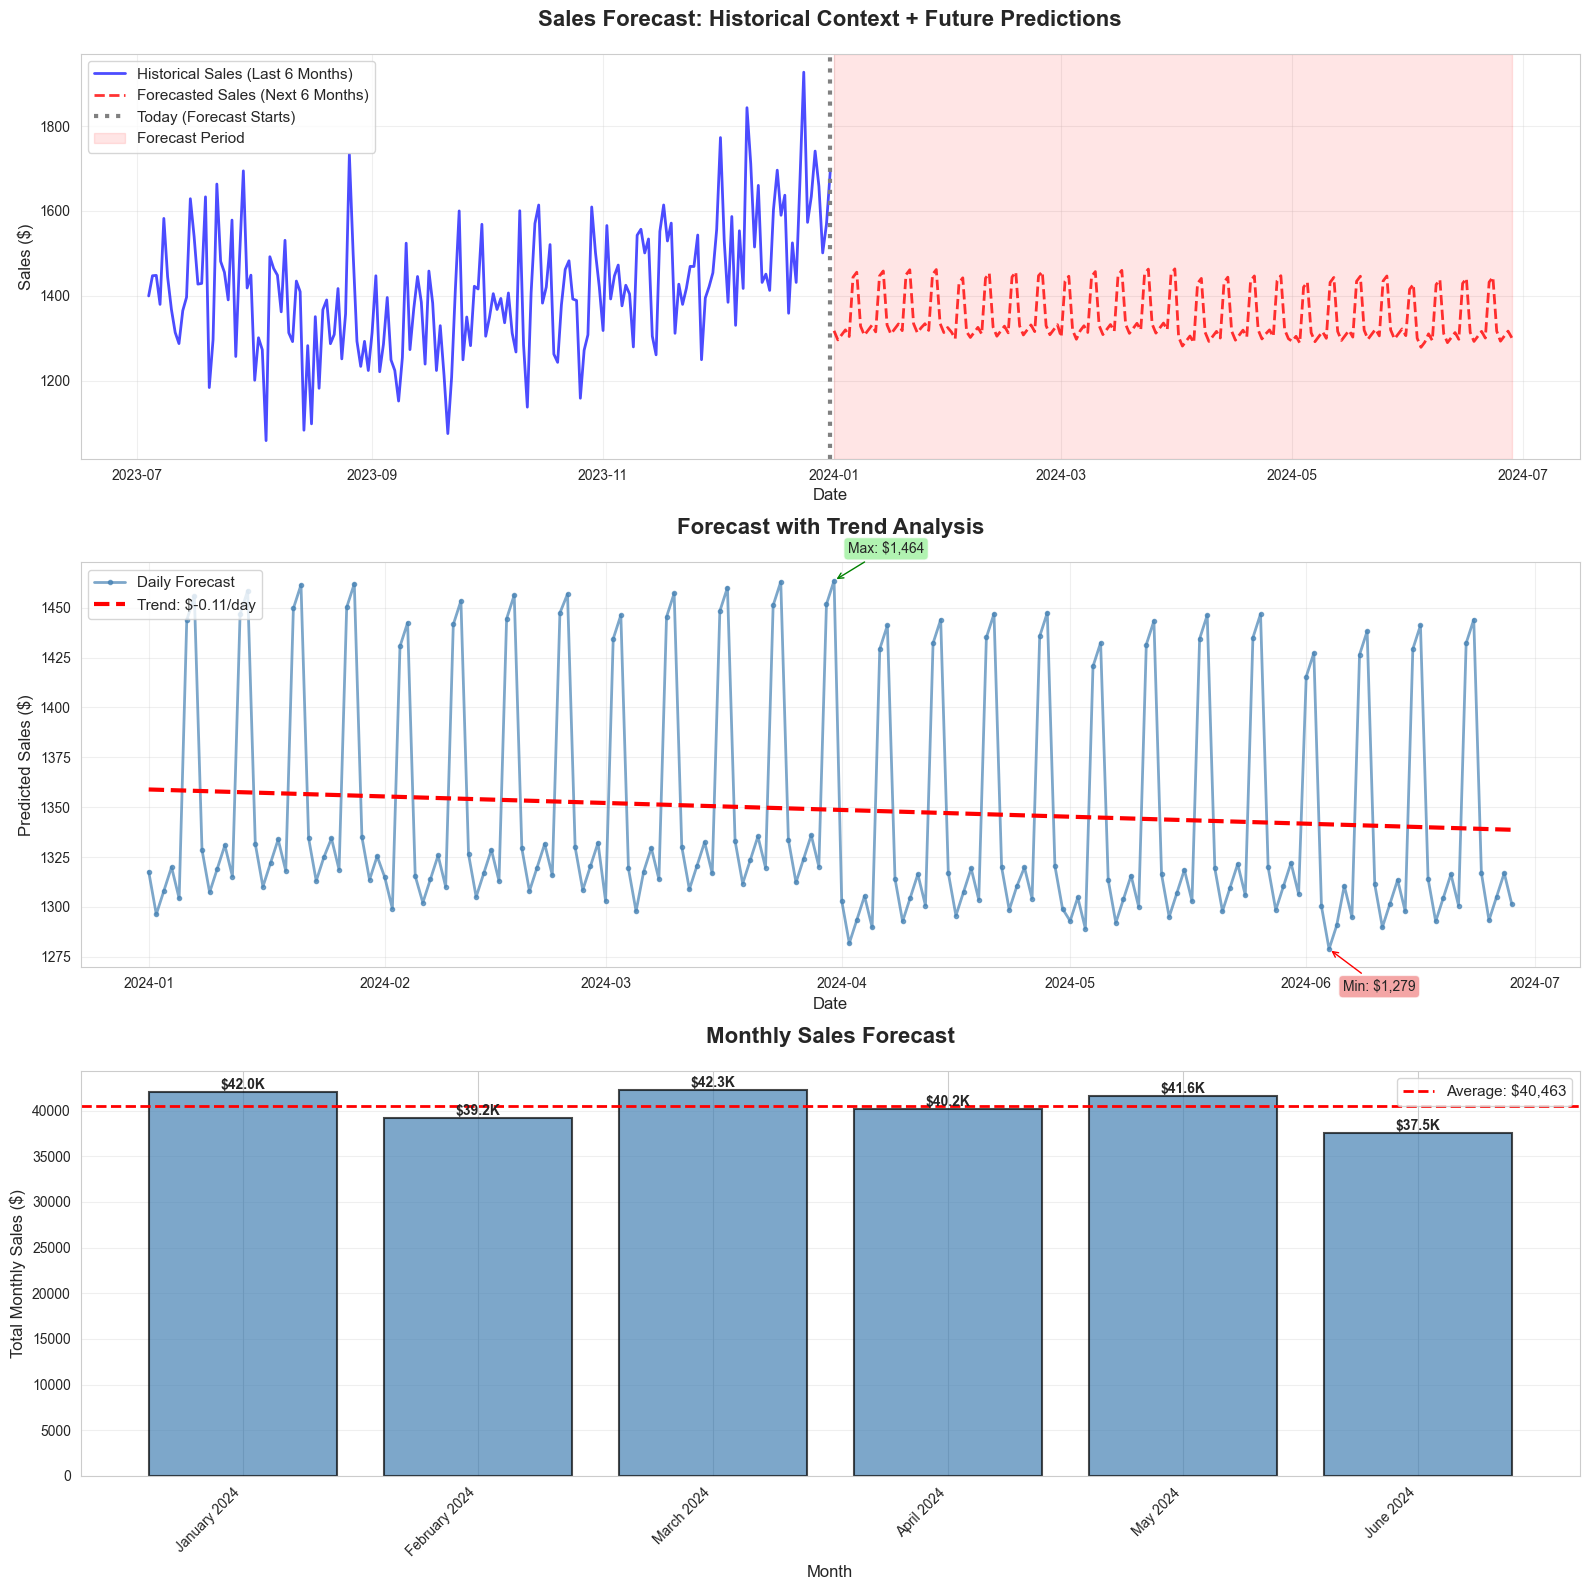

In [8]:
"""
STEP 7: Create comprehensive visualizations of our forecast

The predictions visuals - this is crucial for:
1. Understanding the forecast
2. Communicating with stakeholders
3. Spotting any issues
"""

print("="*70)
print("CREATING FORECAST VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(3, 1, figsize=(16, 16))

"""
PLOT 1: Historical Data + Forecast 
"""

# Plot historical data (last 6 months for context)
last_6_months = df[df['Date'] >= (last_date - timedelta(days=180))]

axes[0].plot(last_6_months['Date'], last_6_months['Sales'], 
            label='Historical Sales (Last 6 Months)', 
            color='blue', linewidth=2, alpha=0.7)

axes[0].plot(future_df['Date'], future_df['Predicted_Sales'], 
            label='Forecasted Sales (Next 6 Months)', 
            color='red', linewidth=2, linestyle='--', alpha=0.8)

# Adding vertical line at forecast start
axes[0].axvline(x=last_date, color='gray', linestyle=':', 
               linewidth=3, label='Today (Forecast Starts)')

# Add shaded forecast region
axes[0].axvspan(future_df['Date'].min(), future_df['Date'].max(), 
               alpha=0.1, color='red', label='Forecast Period')

axes[0].set_title('Sales Forecast: Historical Context + Future Predictions', 
                 fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Sales ($)', fontsize=12)
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(True, alpha=0.3)

"""
PLOT 2: Forecast with Trend Line
"""

# Plot forecast
axes[1].plot(future_df['Date'], future_df['Predicted_Sales'], 
            color='steelblue', linewidth=2, alpha=0.7, 
            marker='o', markersize=3, label='Daily Forecast')

# Calculate and plot trend line
x_numeric = np.arange(len(future_df))
z = np.polyfit(x_numeric, future_df['Predicted_Sales'], 1)
p = np.poly1d(z)
trend_line = p(x_numeric)

axes[1].plot(future_df['Date'], trend_line, 
            color='red', linewidth=3, linestyle='--', 
            label=f'Trend: ${z[0]:.2f}/day')

axes[1].set_title('Forecast with Trend Analysis', 
                 fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Predicted Sales ($)', fontsize=12)
axes[1].legend(fontsize=11, loc='upper left')
axes[1].grid(True, alpha=0.3)

# Add annotations
min_val = future_df['Predicted_Sales'].min()
max_val = future_df['Predicted_Sales'].max()
min_date = future_df.loc[future_df['Predicted_Sales'].idxmin(), 'Date']
max_date = future_df.loc[future_df['Predicted_Sales'].idxmax(), 'Date']

axes[1].annotate(f'Min: ${min_val:,.0f}', 
                xy=(min_date, min_val), 
                xytext=(10, -30), textcoords='offset points',
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='red'))

axes[1].annotate(f'Max: ${max_val:,.0f}', 
                xy=(max_date, max_val), 
                xytext=(10, 20), textcoords='offset points',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='green'))

"""
PLOT 3: Monthly Aggregated Forecast
"""

# Aggregate forecast to monthly level
future_df['Year_Month'] = future_df['Date'].dt.to_period('M')
monthly_forecast = future_df.groupby('Year_Month')['Predicted_Sales'].agg(['sum', 'mean', 'count'])
monthly_forecast.index = monthly_forecast.index.to_timestamp()

# Bar plot
x_pos = range(len(monthly_forecast))
bars = axes[2].bar(x_pos, monthly_forecast['sum'], 
                  color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (idx, row) in enumerate(monthly_forecast.iterrows()):
    height = row['sum']
    axes[2].text(i, height, f'${height/1000:.1f}K', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Customize
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([d.strftime('%B %Y') for d in monthly_forecast.index], 
                       rotation=45, ha='right')
axes[2].set_title('Monthly Sales Forecast', fontsize=16, fontweight='bold', pad=20)
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Total Monthly Sales ($)', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')

# Add average line
avg_monthly = monthly_forecast['sum'].mean()
axes[2].axhline(y=avg_monthly, color='red', linestyle='--', 
               linewidth=2, label=f'Average: ${avg_monthly:,.0f}')
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.show()

In [9]:
"""
STEP 8: Export forecast to files

Create downloadable reports that stakeholders can use:
1. CSV file with daily predictions
2. Excel file with multiple sheets (daily + monthly)
3. Summary statistics report
"""

print("="*70)
print("EXPORTING FORECAST REPORTS")
print("="*70)

# Prepare the daily forecast DataFrame for export
export_daily = future_df[['Date', 'Predicted_Sales', 'Month', 'Is_Weekend', 'Quarter']].copy()

# Add helpful columns
export_daily['Day_Name'] = export_daily['Date'].dt.day_name()
export_daily['Week_Number'] = export_daily['Date'].dt.isocalendar().week
export_daily['Month_Name'] = export_daily['Date'].dt.month_name()

# Reorder columns for better readability
export_daily = export_daily[['Date', 'Day_Name', 'Week_Number', 'Month_Name', 
                             'Quarter', 'Is_Weekend', 'Predicted_Sales']]

# Rename for clarity
export_daily = export_daily.rename(columns={
    'Date': 'Forecast_Date',
    'Day_Name': 'Day_of_Week',
    'Week_Number': 'Week',
    'Month_Name': 'Month',
    'Is_Weekend': 'Weekend',
    'Predicted_Sales': 'Predicted_Sales_USD'
})

# Format Weekend column
export_daily['Weekend'] = export_daily['Weekend'].map({0: 'No', 1: 'Yes'})

print(f"\nDaily forecast prepared")
print(f"   Rows: {len(export_daily)}")
print(f"   Columns: {list(export_daily.columns)}")

# Prepare monthly summary
monthly_summary = future_df.copy()
monthly_summary['Year_Month'] = monthly_summary['Date'].dt.to_period('M')

monthly_export = monthly_summary.groupby('Year_Month').agg({
    'Predicted_Sales': ['sum', 'mean', 'min', 'max', 'std'],
    'Date': 'count'
}).round(2)

# Flatten column names
monthly_export.columns = ['Total_Sales', 'Average_Daily_Sales', 'Min_Daily_Sales', 
                         'Max_Daily_Sales', 'Std_Dev', 'Number_of_Days']
monthly_export = monthly_export.reset_index()
monthly_export['Year_Month'] = monthly_export['Year_Month'].astype(str)

print(f"\nMonthly summary prepared")
print(f"   Rows: {len(monthly_export)}")

# Create output directory if it doesn't exist
import os
output_dir = 'data/forecasts'
os.makedirs(output_dir, exist_ok=True)

# Export to CSV (simple, universal format)
csv_path = f'{output_dir}/sales_forecast_daily.csv'
export_daily.to_csv(csv_path, index=False)

print(f"\nCSV file created:")
print(f"   {csv_path}")

# Export to Excel with multiple sheets
excel_path = f'{output_dir}/sales_forecast_complete.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Sheet 1: Daily forecast
    export_daily.to_excel(writer, sheet_name='Daily Forecast', index=False)
    
    # Sheet 2: Monthly summary
    monthly_export.to_excel(writer, sheet_name='Monthly Summary', index=False)
    
    # Sheet 3: Model information
    model_info = pd.DataFrame({
        'Metric': ['Model Type', 'Training R²', 'Testing R²', 'Testing MAE', 
                  'Training Date Range', 'Forecast Start Date', 'Forecast End Date',
                  'Number of Features', 'Forecast Created'],
        'Value': [
            'Linear Regression',
            f'{model_package["train_r2"]:.4f}',
            f'{model_package["test_r2"]:.4f}',
            f'${model_package["test_mae"]:,.2f}',
            f'{model_package["train_date_range"][0].date()} to {model_package["train_date_range"][1].date()}',
            f'{future_df["Date"].min().date()}',
            f'{future_df["Date"].max().date()}',
            f'{len(feature_names)}',
            f'{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}'
        ]
    })
    model_info.to_excel(writer, sheet_name='Model Info', index=False)
    
    # Sheet 4: Feature importance (top 15)
    top_features_export = feature_importance.head(15)[['Feature', 'Coefficient', 'Impact']].copy()
    top_features_export.to_excel(writer, sheet_name='Feature Importance', index=False)

print(f"\nExcel file created:")
print(f"   {excel_path}")
print(f"   Sheets: Daily Forecast, Monthly Summary, Model Info, Feature Importance")

# Create a summary text report
summary_path = f'{output_dir}/forecast_summary.txt'

with open(summary_path, 'w') as f:
    f.write("="*70 + "\n")
    f.write("SALES FORECAST SUMMARY REPORT\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Forecast Period: {future_df['Date'].min().date()} to {future_df['Date'].max().date()}\n")
    f.write(f"Forecast Horizon: {forecast_months} months ({forecast_days} days)\n\n")
    
    f.write("="*70 + "\n")
    f.write("MODEL PERFORMANCE\n")
    f.write("="*70 + "\n")
    f.write(f"Model Type: Linear Regression\n")
    f.write(f"Testing R² Score: {test_r2:.4f} ({test_r2*100:.2f}%)\n")
    f.write(f"Testing MAE: ${test_mae:,.2f}\n")
    f.write(f"Interpretation: Model explains {test_r2*100:.1f}% of sales variation\n\n")
    
    f.write("="*70 + "\n")
    f.write("FORECAST STATISTICS\n")
    f.write("="*70 + "\n")
    f.write(f"Average Daily Sales: ${future_predictions.mean():,.2f}\n")
    f.write(f"Minimum Daily Sales: ${future_predictions.min():,.2f}\n")
    f.write(f"Maximum Daily Sales: ${future_predictions.max():,.2f}\n")
    f.write(f"Standard Deviation: ${future_predictions.std():,.2f}\n")
    f.write(f"Total Forecast ({forecast_months} months): ${future_predictions.sum():,.2f}\n\n")
    
    f.write("="*70 + "\n")
    f.write("COMPARISON WITH HISTORICAL DATA\n")
    f.write("="*70 + "\n")
    f.write(f"Historical Average Daily Sales: ${historical_avg:,.2f}\n")
    f.write(f"Forecast Average Daily Sales: ${forecast_avg:,.2f}\n")
    f.write(f"Change: ${difference:,.2f} ({pct_change:+.2f}%)\n\n")
    
    f.write("="*70 + "\n")
    f.write("MONTHLY BREAKDOWN\n")
    f.write("="*70 + "\n")
    for idx, row in monthly_export.iterrows():
        f.write(f"\n{row['Year_Month']}:\n")
        f.write(f"  Total Sales: ${row['Total_Sales']:,.2f}\n")
        f.write(f"  Avg Daily: ${row['Average_Daily_Sales']:,.2f}\n")
        f.write(f"  Days: {int(row['Number_of_Days'])}\n")
    
    f.write("\n" + "="*70 + "\n")
    f.write("TOP 5 MOST IMPORTANT FEATURES\n")
    f.write("="*70 + "\n")
    for idx, row in feature_importance.head(5).iterrows():
        f.write(f"\n{idx+1}. {row['Feature']}\n")
        f.write(f"   Coefficient: ${row['Coefficient']:,.2f}\n")
        f.write(f"   Impact: {row['Impact']}\n")
    
    f.write("\n" + "="*70 + "\n")
    f.write("BUSINESS RECOMMENDATIONS\n")
    f.write("="*70 + "\n\n")
    
    # Generate smart recommendations based on analysis
    if pct_change > 10:
        f.write("GROWTH OPPORTUNITY:\n")
        f.write(f"   Sales are projected to increase by {pct_change:.1f}%.\n")
        f.write("   Recommendation: Increase inventory and staffing accordingly.\n\n")
    elif pct_change < -10:
        f.write("DECLINING TREND:\n")
        f.write(f"   Sales are projected to decrease by {abs(pct_change):.1f}%.\n")
        f.write("   Recommendation: Review marketing strategy and cost controls.\n\n")
    else:
        f.write("STABLE TREND:\n")
        f.write("   Sales are projected to remain relatively stable.\n")
        f.write("   Recommendation: Maintain current operations.\n\n")
    
    # Weekend analysis
    weekend_coef = feature_importance[feature_importance['Feature'] == 'Is_Weekend']['Coefficient'].values
    if len(weekend_coef) > 0 and weekend_coef[0] > 100:
        f.write("WEEKEND IMPACT:\n")
        f.write(f"   Weekends add approximately ${weekend_coef[0]:,.2f} to daily sales.\n")
        f.write("   Recommendation: Ensure adequate weekend staffing and inventory.\n\n")
    
    # Seasonal pattern
    q4_coef = feature_importance[feature_importance['Feature'] == 'Is_Q4']['Coefficient'].values
    if len(q4_coef) > 0 and q4_coef[0] > 50:
        f.write("SEASONAL PATTERN:\n")
        f.write(f"   Q4 (Oct-Dec) adds approximately ${q4_coef[0]:,.2f} to daily sales.\n")
        f.write("   Recommendation: Prepare for holiday season demand surge.\n\n")
    
    f.write("="*70 + "\n")
    f.write("END OF REPORT\n")
    f.write("="*70 + "\n")

print(f"\nSummary report created:")
print(f"   {summary_path}")

# Create a quick reference card
reference_path = f'{output_dir}/forecast_quick_reference.txt'

with open(reference_path, 'w') as f:
    f.write("║         SALES FORECAST - QUICK REFERENCE CARD              ║\n")
    
    f.write(f"Forecast Period: {future_df['Date'].min().strftime('%b %d, %Y')} - {future_df['Date'].max().strftime('%b %d, %Y')}\n")
    f.write(f"Generated: {datetime.now().strftime('%b %d, %Y at %I:%M %p')}\n\n")
    
    f.write("KEY METRICS:\n")
    f.write("─" * 60 + "\n")
    f.write(f"Average Daily Sales:     ${future_predictions.mean():>12,.2f}\n")
    f.write(f"Total {forecast_months}-Month Forecast: ${future_predictions.sum():>12,.2f}\n")
    f.write(f"Model Accuracy (R²):     {test_r2*100:>12.1f}%\n")
    f.write(f"vs Historical:           {pct_change:>12.1f}%\n\n")
    
    f.write("MONTHLY TOTALS:\n")
    f.write("─" * 60 + "\n")
    for idx, row in monthly_export.iterrows():
        month_name = pd.to_datetime(row['Year_Month']).strftime('%B %Y')
        f.write(f"{month_name:20s} ${row['Total_Sales']:>12,.2f}\n")
    
    f.write("\n" + "─" * 60 + "\n")
    f.write("Files Generated:\n")
    f.write(f"  • {os.path.basename(csv_path)} (daily data)\n")
    f.write(f"  • {os.path.basename(excel_path)} (complete workbook)\n")
    f.write(f"  • {os.path.basename(summary_path)} (detailed report)\n")

print(f"\nQuick reference created:")
print(f"   {reference_path}")

print("\n" + "="*70)
print("ALL FILES EXPORTED SUCCESSFULLY!")
print("="*70)

print(f"\nLocation: {output_dir}/")
print("\nFiles created:")
print(f"  1. sales_forecast_daily.csv")
print(f"  2. sales_forecast_complete.xlsx")
print(f"  3. forecast_summary.txt")
print(f"  4. forecast_quick_reference.txt")

# Show file sizes
print("\nFile sizes:")
for filename in os.listdir(output_dir):
    filepath = os.path.join(output_dir, filename)
    if os.path.isfile(filepath):
        size = os.path.getsize(filepath)
        print(f"   {filename:40s} {size:>10,} bytes ({size/1024:>6.1f} KB)")

EXPORTING FORECAST REPORTS

Daily forecast prepared
   Rows: 180
   Columns: ['Forecast_Date', 'Day_of_Week', 'Week', 'Month', 'Quarter', 'Weekend', 'Predicted_Sales_USD']

Monthly summary prepared
   Rows: 6

CSV file created:
   ../data/forecasts/sales_forecast_daily.csv

Excel file created:
   ../data/forecasts/sales_forecast_complete.xlsx
   Sheets: Daily Forecast, Monthly Summary, Model Info, Feature Importance

Summary report created:
   ../data/forecasts/forecast_summary.txt

Quick reference created:
   ../data/forecasts/forecast_quick_reference.txt

ALL FILES EXPORTED SUCCESSFULLY!

Location: ../data/forecasts/

Files created:
  1. sales_forecast_daily.csv
  2. sales_forecast_complete.xlsx
  3. forecast_summary.txt
  4. forecast_quick_reference.txt

File sizes:
   forecast_summary.txt                          2,700 bytes (   2.6 KB)
   sales_forecast_complete.xlsx                 15,309 bytes (  15.0 KB)
   sales_forecast_daily.csv                      9,469 bytes (   9.2 KB)
 